In [11]:
from pinecone import Pinecone, ServerlessSpec
from dotenv import load_dotenv
import os
# Load environment variables
load_dotenv()
# Get API key for Euri
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
EURI_API_KEY = os.getenv("EURI_API_KEY")



c:\Users\NoorNahiyanB\AppData\Local\anaconda3\envs\genai\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
pip install weaviate-client

  Using cached validators-0.34.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached pycparser-2.22-py3-none-any.whl.metadata (943 bytes)
Using cached validators-0.34.0-py3-none-any.whl (43 kB)
   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ---------------------------- ----------- 0.8/1.1 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 4.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   -------------------------- ------------- 1.3/2.0 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 6.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ------------- -------------------------- 1.0/3.2 MB 5.0 MB/s eta 0:00:01
   -------------------------- ------------- 2.1/3.2 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 5.2 MB/s eta 0:00:00
Using cached pycparser-2.22-py3-none-any.whl (117 kB)
  Attempting un

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
chromadb 0.4.4 requires pydantic<2.0,>=1.9, but you have pydantic 2.11.4 which is incompatible.
fastapi 0.99.1 requires pydantic!=1.8,!=1.8.1,<2.0.0,>=1.7.4, but you have pydantic 2.11.4 which is incompatible.


In [12]:
import os
import weaviate
from dotenv import load_dotenv
from weaviate.classes.init import Auth

# Load environment variables from a .env file
load_dotenv()

# Correct function usage
weaviate_url = os.getenv("WEAVIATE_URL")
weaviate_api_key = os.getenv("WEAVIATE_API_KEY")

# Connect to Weaviate Cloud
client = weaviate.connect_to_weaviate_cloud(
    cluster_url=weaviate_url,
    auth_credentials=Auth.api_key(weaviate_api_key),
)

print(client.is_ready())


True


c:\Users\NoorNahiyanB\AppData\Local\anaconda3\envs\genai\Lib\site-packages\weaviate\warnings.py:314: ResourceWarning: Con004: The connection to Weaviate was not closed properly. This can lead to memory leaks.
            Please make sure to close the connection using `client.close()`.
  warnings.warn(
C:\Users\NoorNahiyanB\AppData\Local\Temp\ipykernel_74536\3611512930.py:14: ResourceWarning: unclosed <ssl.SSLSocket fd=2116, family=2, type=1, proto=0, laddr=('192.168.0.5', 57614), raddr=('34.36.172.118', 443)>
  client = weaviate.connect_to_weaviate_cloud(


In [13]:
import requests
import numpy as np

def generate_embeddings(data):
    url = "https://api.euron.one/api/v1/euri/alpha/embeddings"
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {EURI_API_KEY}"
    }
    payload = {
        "input":data,
        "model": "text-embedding-3-small"
    }

    response = requests.post(url, headers=headers, json=payload)
    data = response.json()
    
    # Convert to numpy array for vector operations
    embedding = np.array(data['data'][0]['embedding'])
    
    print(f"Generated embedding with shape: {embedding.shape}")
    print(f"First 5 values: {embedding[:5]}")
    
    # Example: Calculate vector norm
    norm = np.linalg.norm(embedding)
    print(f"Vector norm: {norm}")
    
    return embedding

In [15]:
text_data = "I am Nahiyan, I am trying to connect with weaviate. Weaviate is a vector database where we can store vector representations of text"
embeddings = generate_embeddings(text_data)

Generated embedding with shape: (1536,)
First 5 values: [-0.02072883  0.01169785  0.0340497   0.00590617 -0.01763095]
Vector norm: 0.9999999815401985


In [18]:
collection = client.collections.create("Document1")
collection.data.insert(
    properties = {
        "text" :text_data,
        "author":"Nahiyan"
    },
    vector =embeddings.tolist()
    
)

UUID('d251c763-a179-41f6-9b61-ab0b87ef2b88')

In [ ]:
collection = client.collections.get("Document1")
collection.data.insert(
    properties = {
        "text" :text_data,
        "author":"Nahiyan"
    },
    vector =embeddings.tolist()
)

In [19]:
test_search = "Weaviate is vector database"
embedings_search_data = generate_embeddings(test_search)

result = collection.query.near_vector(
    near_vector = embedings_search_data.tolist(),
    limit = 1 
)

Generated embedding with shape: (1536,)
First 5 values: [-0.00859952  0.03029812  0.03356919 -0.00638673 -0.06027061]
Vector norm: 1.0000000136581577


In [20]:
for i in result.objects:
    print(i.properties['text'])

I am Nahiyan, I am trying to connect with weaviate. Weaviate is a vector database where we can store vector representations of text


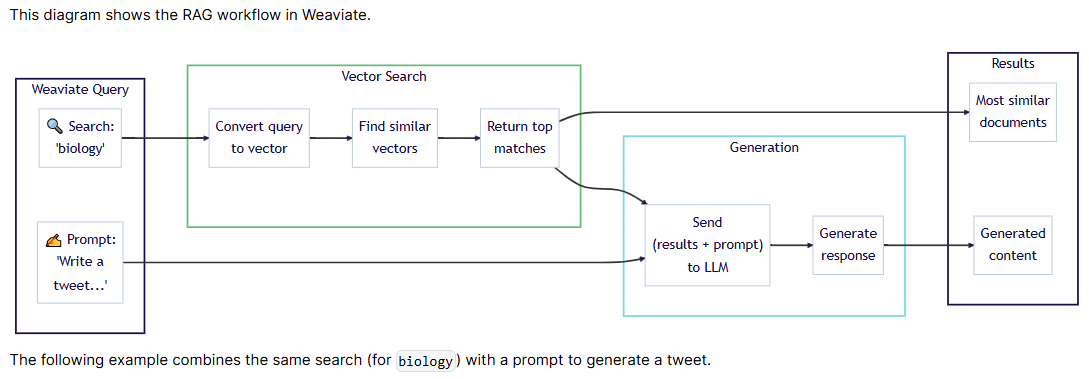